# Lab 7: Function approximation + Tile Coding + Semi-gradient SARSA in Mountain Car (Sutton & Barto Example 10.1)

## Learning objectives
In this lab, we will
- implement **tile coding** features for continuous states
- implement **semi-gradient SARSA** with a **linear function approximator**
- train on the **Mountain Car** task and analyze learning curves

**Reminder:** In Mountain Car, the agent must often go *left first* to build momentum and then reach the goal on the right.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)

## 1. Environment: Mountain Car

The Mountain Car problem is a classic benchmark in Reinforcement Learning designed to highlight the challenges of
continuous state spaces. 

**State Space.**
At each time step, the agent observes a continuous state $s=(x,v)$, where 

- position $x \in [-1.2, 0.5]$ represents the horizontal location of the car along a valley between two hills.

- velocity $v \in [-0.07, 0.07]$ represents the car’s speed (positive = moving right, negative = moving left).

The state space is continuous and two-dimensional, which means the tabular methods are not directly applicable.

**Action Space.** The agent can choose one of three discrete actions $a\in\{-1,0,1\}$

-1: push the car to the left

0: no push

+1: push the car to the right

Remark. The car’s engine is not powerful enough to drive directly up the right hill to the goal. As a result, simply pushing right all the time fails. The agent must first move left, build momentum, and then accelerate right.

**Reward.** 
- $r_t=-1$ each step until the car reaches the goal ($x\ge 0.5$). Then the episode terminates.




In [12]:
class MountainCar:
    """Minimal Mountain Car environment with continuous state space (position, velocity) discrete action space (push left / no push / push right).

    This implementation follows the classic Mountain Car dynamics
    used in Sutton & Barto.
    """

    def __init__(self, seed: int = 0) -> None:
        """Initialize the Mountain Car environment. Optionally set a random seed for reproducibility."""
        # Create a dedicated random number generator for this environment.
        # Using a local RNG for reproducibility
        # and avoids interference with randomness used elsewhere.
        self.rng = np.random.default_rng(seed)

        # Initialize the environment to a valid starting state.
        # This sets self.x and self.v and returns the initial state.
        self.reset()

    def reset(self) -> np.ndarray:
        """Reset the environment at the beginning of a new episode."""
        # Sample the initial position uniformly in a small interval
        # around the bottom of the valley (approximately x = -0.5).
        # Starting here ensures the task is non-trivial and requires momentum.
        self.x = float(self.rng.uniform(-0.6, -0.4))

        # Initial velocity is set to zero (no initial momentum).
        self.v = 0.0

        # Return the initial state as a NumPy array: [position, velocity]
        # Using float64 ensures numerical consistency and stability.
        return np.array([self.x, self.v], dtype=np.float64)

    @staticmethod
    def step_dynamics(x: np.ndarray, v: float, a: int) -> tuple[float, float]:
        """Compute the next state given current position x, velocity v, and action a."""
        # This function is static because it does not depend
        # on any internal state of the environment object.

        # Update the velocity using the Mountain Car physics:
        #  - 0.001 * a      : acceleration from the engine
        #  - -0.0025*cos(3x): gravity pulling the car downhill
        #
        # Important: the engine alone is not strong enough
        # to push the car directly to the goal.
        v = v + 0.001 * a - 0.0025 * np.cos(3 * x)

        # Clip the velocity to its allowed range.
        # This prevents unrealistic speeds and numerical instability.
        v = float(np.clip(v, -0.07, 0.07))

        # Update the position using the new velocity.
        x = x + v

        # Clip the position to the allowed interval.
        # The right boundary (0.5) corresponds to the goal.
        x = np.clip(x, -1.2, 0.5)

        # If the car hits the left boundary,
        # its velocity is reset to zero.
        # This models an inelastic collision with the wall
        # and matches the standard Mountain Car convention.
        if x <= -1.2:  # noqa: PLR2004
            v = 0.0

        # Return the updated continuous state.
        return x, v

    def step(self, a: int) -> tuple[np.ndarray, float, bool]:
        """Take an action a and return the next state, reward, and done flag."""
        # Update the internal state (x, v) using the dynamics function.
        # Action is explicitly cast to int to avoid type issues
        # (e.g., when actions come from NumPy arrays or policies).
        self.x, self.v = MountainCar.step_dynamics(self.x, self.v, int(a))  # ty:ignore[invalid-argument-type]

        # Construct the next state as a NumPy array
        # to be returned to the agent.
        s = np.array([self.x, self.v], dtype=np.float64)

        # Check whether the episode has terminated.
        # The episode ends once the car reaches the goal position.
        done = bool(self.x >= 0.5)  # noqa: PLR2004

        # Reward structure:
        #  - reward = -1 at every time step
        #  - reward = 0 when the goal is reached (terminal state)
        #
        # This encourages the agent to reach the goal
        # in as few steps as possible.
        r = 0.0 if done else -1.0

        # Return the standard RL tuple: (next_state, reward, done)
        return s, r, done


Before implementing any learning algorithm, we first establish a baseline by running the Mountain Car environment with a random policy.

In [13]:
# Create an instance of the Mountain Car environment.
# The seed fixes the randomness so that results are reproducible
# (same initial states and same random action sequences).
env = MountainCar(seed=0)

# Define the discrete action space explicitly:
#  -1 : push left
#   0 : no push
#  +1 : push right
# Storing actions in an array makes random sampling and later policies easier.
ACTIONS = np.array([-1, 0, +1], dtype=int)

# Reset the environment to start a new episode.
# This initializes the position and velocity and returns the initial state.
s = env.reset()

# Counter to track how many time steps are taken in this episode.
# Episode length is the main performance metric in Mountain Car.
steps = 0

# Run the episode until termination.
# We use an infinite loop and manually break when the episode ends.
while True:
    # Select an action uniformly at random from the action set.
    # This corresponds to a random (uninformed) policy.
    a = int(rng.choice(ACTIONS))

    # Apply the chosen action to the environment.
    # This returns:
    #  - s    : next state (position, velocity)
    #  - r    : reward obtained after the action
    #  - done : whether the episode has terminated
    s, r, done = env.step(a)

    # Increment the step counter.
    steps += 1

    # Stop the episode if:
    #  - the goal is reached (done == True), or
    #  - a safety cap on episode length is exceeded
    #    (prevents infinite loops under bad policies).
    if done or steps > 10000:  # noqa: PLR2004
        break

# Print the episode length obtained under the random policy.
# Since reward is -1 at each step, shorter episodes correspond
# to higher total return.
print(f"Random-policy episode length: {steps} steps")


Random-policy episode length: 7452 steps


## 2. Tile Coding for Continuous State Spaces

In the Mountain Car problem, the state $s=(x,v)$ (position and velocity) is continuous.
This means that classic tabular methods (one value per state or per state–action pair) are not feasible: there are infinitely many possible states. To apply value-based control methods such as SARSA or Q-learning, we therefore need a function approximation technique that handles continuous inputs and is simple and interpretable,

In this lab, we use **tile coding**.

**Principle of tile coding**

Tile coding approximates a continuous state space by combining multiple coarse discretizations, called tilings.

Each tiling is a regular grid over the $(x,v)$ space.

The grids are slightly shifted relative to each other.

For a given state $s$: exactly one tile is active in each tiling, all other tiles are inactive.

As a result, the feature vector $\varphi(s)$ is sparse, nearby states activate overlapping but not identical sets of tiles.

**Why multiple tilings?**

Using a single grid leads to hard discretization boundaries: two very close states may fall into different bins and share no information.

By using multiple offset tilings: nearby states share some active tiles, distant states share few or none, the representation is both smooth and expressive.

This gives a good tradeoff: with coarse tiles $\rightarrow$ generalization and multiple tilings $\rightarrow$ precision.

**Action-dependent features**

In control problems, we need to approximate the action-value function $q(s,a)$. To do this, tile coding is extended to state–action pairs, that is, **each action has its own set of tilings and features for different actions do not overlap.**

**Sparse linear approximation**

In this lab, the approximate action-value function takes the form $\hat{q}(s,a)=\sum_{i\in\mathcal{I}(s,a)}w_i$, where $\mathcal{I}(s,a)$ is the set of active tile indices. 

In fact, by using this expression, computation is fast since only a few weights are used.

In [14]:
class TileCoder:
    """Tile coding feature representation for Mountain Car with continuous states.

    The idea:
    - The state s = (x, v) is continuous and cannot be handled with a tabular method.
    - We discretize the state space using multiple overlapping grids (tilings).
    - Each tiling maps a continuous state to exactly ONE active tile.
    - Using multiple shifted tilings allows generalization while preserving resolution.

    For a given (state, action) pair:
    - Exactly one tile is active per tiling.
    - Therefore, the feature vector phi(s,a) has exactly `n_tilings` active components (equal to 1).

    Implementation detail:
    - We never explicitly build the full phi(s,a) vector of size d.
    - Instead, we return the indices of the active features.
    - This allows efficient computation of q(s,a) = sum(w[idx]) and efficient weight updates.
    """

    def __init__(  # noqa: PLR0913
        self,
        x_range: tuple[float, float] = (-1.2, 0.5),
        v_range: tuple[float, float] = (-0.07, 0.07),
        n_tilings: int = 8,
        n_x: int = 8,
        n_v: int = 8,
        n_actions: int = 3,
    ) -> None:
        """Initialize the TileCoder with specified parameters."""
        # Store the minimum and maximum values for position.
        # These define the bounds of the Mountain Car state space.
        self.x_min, self.x_max = x_range

        # Store the minimum and maximum values for velocity.
        self.v_min, self.v_max = v_range

        # Number of overlapping tilings (grids).
        # More tilings -> better generalization but higher computational cost.
        self.n_tilings = int(n_tilings)

        # Number of tiles along the position dimension per tiling.
        self.n_x = int(n_x)

        # Number of tiles along the velocity dimension per tiling.
        self.n_v = int(n_v)

        # Number of discrete actions.
        # For Mountain Car: {-1, 0, +1} → 3 actions.
        self.n_actions = int(n_actions)

        # Number of tiles in ONE tiling (2D grid).
        # Each tiling is an n_x by n_v grid.
        self.tiles_per_tiling = self.n_x * self.n_v

        # Total number of features:
        # action x tiling x tile
        #
        # Each action has its own independent set of tilings.
        # This corresponds to using separate value functions for each action.
        self.d = self.n_actions * self.n_tilings * self.tiles_per_tiling

        # Compute tile width along the position dimension.
        # This is the spacing between neighboring tile centers.
        #
        # Using (n_x - 1) ensures that x_min and x_max lie exactly
        # on the grid boundaries.
        self.x_w = (self.x_max - self.x_min) / (self.n_x - 1)

        # Compute tile width along the velocity dimension.
        self.v_w = (self.v_max - self.v_min) / (self.n_v - 1)

        # Offsets for each tiling in the position dimension.
        # Each tiling is shifted slightly relative to the others.
        #
        # This creates overlapping grids, which is the key idea
        # behind tile coding generalization.
        self.x_offsets = np.linspace(0.0, self.x_w, self.n_tilings, endpoint=False)

        # Offsets for each tiling in the velocity dimension.
        # We use the same number of offsets as tilings.
        self.v_offsets = np.linspace(0.0, self.v_w, self.n_tilings, endpoint=False)

    def _action_id(self, a: int) -> int:
        """Convert environment action values {-1, 0, +1} into internal action indices {0, 1, 2}.

        This mapping is necessary because array indexing
        must start from 0.
        """
        # Push left → index 0
        if a == -1:
            return 0

        # No push → index 1
        if a == 0:
            return 1

        # Push right → index 2
        if a == +1:
            return 2

        # Any other value is invalid.
        error = "Action must be one of {-1, 0, +1}."
        raise ValueError(error)

    def encode(self, s: np.ndarray, a: int) -> np.ndarray:
        """Compute the active tile indices for a given (state, action) pair.

        Args:
            s : np.array([x, v])
                Continuous Mountain Car state.
            a : int
                Action in {-1, 0, +1}.

        Returns:
            idx : np.array of shape (n_tilings,)
                Indices of the active features.

        Indexing scheme:
            global_index =
                ((action_id * n_tilings + tiling_id) * tiles_per_tiling)
                + tile_id

        where:
            tile_id = ix * n_v + iv

        """
        # Extract continuous position and velocity from the state.
        # Convert explicitly to float for numerical safety.
        x, v = float(s[0]), float(s[1])

        # Convert the environment action into an internal action index.
        action_id = self._action_id(int(a))

        # Allocate an array to store the active feature index
        # for each tiling.
        idx = np.empty(self.n_tilings, dtype=np.int64)

        # Loop over all tilings.
        # Each tiling produces exactly one active tile.
        for k in range(self.n_tilings):
            # 1) Apply the tiling-specific offset.
            # This shifts the grid so that different tilings
            # partition the space differently.
            xk = x + self.x_offsets[k]
            vk = v + self.v_offsets[k]

            # 2) Convert continuous coordinates to discrete grid indices.
            #
            # Subtract the minimum value, divide by tile width,
            # and round down to get the tile index.
            ix = int(np.floor((xk - self.x_min) / self.x_w))
            iv = int(np.floor((vk - self.v_min) / self.v_w))

            # 3) Clamp indices to valid ranges.
            # This handles boundary cases where rounding
            # might push indices outside the grid.
            ix = int(np.clip(ix, 0, self.n_x - 1))
            iv = int(np.clip(iv, 0, self.n_v - 1))

            # 4) Flatten the 2D tile index (ix, iv)
            # into a single tile_id.
            #
            # This is row-major ordering.
            tile_id = ix * self.n_v + iv

            # 5) Compute the global feature index.
            #
            # Layout: [ action ] [ tiling ] [ tile ]  # noqa: ERA001
            #
            # This ensures that:
            # - different actions do not share features,
            # - each tiling has its own independent grid.
            idx[k] = (action_id * self.n_tilings + k) * self.tiles_per_tiling + tile_id

        # Return the list of active feature indices.
        # The corresponding feature values are implicitly 1.
        return idx


**Exercise 1.** In this exercise, we study how tile coding maps continuous states to sparse feature representations and how it provides generalization across nearby states. 

Question 1 - Run the code below and note the value of the feature dimension $d$. Write down the formula used to compute d in terms of number of actions, number of tilings and number of tiles per tiling.

In [15]:
tc = TileCoder(n_tilings=4, n_x=8, n_v=8)
print("Feature dimension d =", tc.d)

Feature dimension d = 768


Question 2 - We now test how tile coding behaves for two nearby states. Explain why we fix the action to -1 in this experiment. What does the variable `shared` measure? 

In [16]:
s1 = np.array([-0.50, 0.00])
s2 = np.array([-0.49, 0.00])  # change the value of s2 and test
idx1 = set(tc.encode(s1, -1).tolist())
idx2 = set(tc.encode(s2, -1).tolist())
shared = len(idx1.intersection(idx2))
print(f"Shared active tiles between nearby states: {shared}/{tc.n_tilings}")

Shared active tiles between nearby states: 4/4


## 3. Semi-gradient SARSA with linear function approximation


We now combine **tile coding** with a **control algorithm** to learn how to solve the Mountain Car task.

Since the state space $(x,v)$ is continuous, we cannot use a tabular representation for the action-value function $q(s,a)$. Instead, we use **linear function approximation** together with the tile-coded features introduced earlier.

**Objective**

Our goal is to approximate the action-value function:
$$
q_\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a]
$$
using a parameterized model:
$$
\hat q(s,a; \mathbf{w}) = \mathbf{w}^\top \phi(s,a),
$$
where:
- $\phi(s,a)$ is a **sparse binary feature vector** produced by tile coding (see Section 2.),
- $\mathbf{w}$ is a vector of learnable weights.

Because tile coding activates **exactly one tile per tiling**, $\phi(s,a)$ has exactly `n_tilings` non-zero entries. This means
$$
\hat q(s,a) = \sum_{i \in \mathcal{I}(s,a)} w_i,
$$
where $\mathcal{I}(s,a)$ is the set of active feature indices.

**Algorithm: Semi-gradient SARSA**

We use **SARSA**, an on-policy temporal-difference control algorithm.

At each time step, given a transition
$$
(s, a, r, s', a'),
$$
the **TD error** is computed as:
$$
\delta =
\begin{cases}
r - \hat q(s,a), & \text{if } s' \text{ is terminal}, \\
r + \gamma \hat q(s',a') - \hat q(s,a), & \text{otherwise}.
\end{cases}
$$

The **semi-gradient update** for linear function approximation is:
$$
w_i \leftarrow w_i + \alpha \, \delta
\quad \text{for all } i \in \mathcal{I}(s,a).
$$

Only the weights corresponding to **active tiles** are updated.

**Step-Size Scaling**

Each state–action pair activates `n_tilings` features.  
To prevent the total update magnitude from growing with the number of tilings, we scale the learning rate as:
$$
\alpha_{\text{effective}} = \frac{\alpha}{n_{\text{tilings}}}.
$$

This is standard practice when using tile coding and improves learning stability.

**Action Selection: $\varepsilon$-Greedy Policy**

The agent follows an **$\varepsilon$-greedy policy** with respect to $\hat q(s,a)$:

- with probability $\varepsilon$: select a random action (exploration),
- with probability $1-\varepsilon$: select an action maximizing $\hat q(s,a)$ (exploitation),
- ties are broken uniformly at random.




**Exercise 2.**  Complete the following code cell to implement the **SARSA algorithm** for the **Mountain Car** problem.  There are **only 3 `# TODO` items** to do.




In [17]:
# Define the discrete action set for Mountain Car.
# We keep the environment's natural action encoding:
#   -1 : push left
#    0 : no push
#   +1 : push right
ACTIONS = np.array([-1, 0, +1], dtype=int)


class SarsaAgent:
    r"""Semi-gradient SARSA agent with linear function approximation for q(s,a) tile coding to build sparse feature representations phi(s,a).

    -----------------------------
    1) Function approximation
    -----------------------------
    We approximate the action-value function q_pi(s,a) by a parameterized function:
        \hat q(s,a; w) = w^T phi(s,a)

    In tile coding, phi(s,a) is a high-dimensional sparse binary vector:
        - dimension can be large
        - but only a small number of entries are 1
        - specifically: exactly n_tilings active entries (one per tiling)

    Therefore, we can compute hat q using
        \hat q(s,a) = sum_{i in active(s,a)} w_i

    And the gradient is also simple:
        gradient_w \hat q(s,a) = phi(s,a)
    which means:
        - gradient is 1 on the active indices
        - gradient is 0 everywhere else

    -----------------------------
    2) SARSA update rule
    -----------------------------
    SARSA is an on-policy TD control method. "Semi-gradient" means
        - we treat the target as a constant w.r.t. w

    TD error (delta):
        delta = r + gamma hat q(s',a') - hat q(s,a)       if not terminal
        delta = r - hat q(s,a)                    if terminal (since hat q(s',a') = 0)

    Weight update:
        w_i <-- w_i + alpha delta  for each active feature i of (s,a)

    -----------------------------
    3) Step-size scaling
    -----------------------------
    With tile coding, each (s,a) activates n_tilings features.
    If we used the same alpha regardless of n_tilings, increasing n_tilings would
    increase the total update magnitude per time step (more weights change).
    To keep learning stable, common practice is:
        alpha_effective = alpha / n_tilings
    """

    def __init__(
        self,
        tilecoder: TileCoder,
        alpha: float = 0.5,
        gamma: float = 1.0,
        epsilon: float = 0.0,
        seed: int = 0,
    ) -> None:
        """Initialize the SARSA agent with given parameters."""
        # Store the tile coder object.
        # This object converts continuous states (x,v) + action into active indices.
        self.tc = tilecoder

        # Discount factor gamma in [0,1].
        # For episodic tasks like Mountain Car, gamma is often set to 1.0.
        self.gamma = float(gamma)

        # Exploration parameter epsilon for epsilon-greedy policy.
        self.epsilon = float(epsilon)

        # for reproducibility.
        self.rng = np.random.default_rng(seed)

        # Scale the learning rate by 1 / n_tilings.
        self.alpha = float(alpha) / self.tc.n_tilings

        # Initialize the parameter vector (weights) w in Rd.
        self.w = np.zeros(self.tc.d, dtype=np.float64)

    def q(self, s: np.ndarray, a: int) -> float:
        """Compute the approximated action-value hat q.

        Because tile coding features are sparse:
            - encode(s,a) returns the indices of active features
            - hat q(s,a) is the sum of weights at these indices
        """
        # Get the indices of the active tiles for (s,a):
        # idx has shape (n_tilings,).
        idx = self.tc.encode(s, a)

        # Sum the corresponding weights. This equals w^T phi(s,a)
        # because phi(s,a) has value 1 at these indices and 0 elsewhere.
        return float(self.w[idx].sum())

    def eps_greedy(self, s: np.ndarray) -> int:
        """Choose an action using an epsilon-greedy policy w.r.t. hat q.

        Policy definition:
            - with probability epsilon: take a random action (exploration)
            - with probability 1-epsilon: take a greedy action (exploitation)

        Tie-breaking:
            - if multiple actions share the same maximal hat q(s,a), choose uniformly among them
        """
        # If it is less than epsilon, we explore.
        if self.rng.random() < self.epsilon:
            # Choose a random action from ACTIONS uniformly.
            return int(self.rng.choice(ACTIONS))

        # Otherwise, we exploit: compute hat q(s,a) for each possible action.
        # This creates a length-3 array of q-values in the order of ACTIONS.
        qs = np.array([self.q(s, int(a)) for a in ACTIONS], dtype=np.float64)

        # Identify the maximal q-value.
        # qs.max() returns the best value; we then find which actions achieve it.
        best = np.flatnonzero(qs == qs.max())

        # If there is a unique best action, best has length 1.
        # If there is a tie, best contains multiple indices.
        # We sample one index uniformly from best to break ties fairly.
        return int(ACTIONS[self.rng.choice(best)])

    def update(  # noqa: PLR0913
        self, s: np.ndarray, a: int, r: float, sp: np.ndarray, ap: int, done: bool,  # noqa: FBT001
    ) -> float:
        """Perform one semi-gradient SARSA update.

        Inputs:
            s    : current state
            a    : current action
            r    : reward observed after taking a in s
            sp   : next state s'
            ap   : next action a' chosen by the current policy
            done : whether s' is terminal

        Steps:
            1) Compute current estimate hat q(s,a)
            2) Compute target:
                r                               if terminal
                r + gamma* hat q(s',a')         otherwise
            3) TD error delta = target - hat q(s,a)
            4) Update only the active weights for (s,a): w[idx] <-- w[idx] + alpha delta
        """
        # Get active feature indices for (s,a).
        # Only these weights contribute to hat q(s,a) and only these weights are updated.
        idx = self.tc.encode(s, a)

        # Compute current hat q(s,a) efficiently as a sum of active weights.
        qsa = float(self.w[idx].sum())

        # Compute the TD target.
        if done:
            # If next state is terminal, by definition there is no future return.
            # So the target is just the immediate reward r.
            target = r
        else:
            # Otherwise, bootstrap from the next state's action-value hat q(s',a').
            # Note: ap must be the action actually selected by the current policy,
            # which is why SARSA is "on-policy".
            qspap = self.q(sp, ap)
            target = r + self.gamma * qspap

        # TD error delta

        delta = target - qsa

        # Semi-gradient update:
        # For linear approximation, the gradient w.r.t. active weights is 1.
        # Therefore each active weight receives the same additive update alpha*delta.
        #
        # Important: because idx has length n_tilings, this single line updates
        # exactly n_tilings weights.
        self.w[idx] += self.alpha * delta

        # Return delta
        return delta


## 4. Training loop and learning curves

We measure performance by **episode length** (number of steps to reach the goal).
Since reward is -1 per step, shorter episodes = higher return.

We implement the training loop below and then run experiments. implement `run_episode` and `train`, then plot the learning curve.


In [18]:
def run_episode(
    env: MountainCar, agent: SarsaAgent, max_steps: int = 10000,
) -> tuple[int, float]:
    """Run one episode with semi-gradient SARSA.

    Algorithmic structure matches Sutton & Barto:
        - choose A from epsilon-greedy policy
        - for each step: take A, observe (R,S')
        - if terminal: update with target R
        - else: choose A' from epsilon-greedy, update with target R + gamma q(S',A')
        - shift (S,A) <- (S',A')

    Returns:
        steps: number of environment steps
        G: total return (sum of rewards)

    """
    s = env.reset()
    a = agent.eps_greedy(s)

    G = 0.0
    for t in range(max_steps):
        sp, r, done = env.step(a)
        G += r

        if done:
            agent.update(s, a, r, sp, ap=0, done=True)  # ap unused when done
            return t + 1, G

        ap = agent.eps_greedy(sp)
        agent.update(s, a, r, sp, ap, done=False)

        s, a = sp, ap

    return max_steps, G


def train(
    seed: int = 0,
    episodes: int = 200,
    tc_kwargs: dict | None = None,
    agent_kwargs: dict | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Train over multiple episodes and collect learning curves."""
    if tc_kwargs is None:
        tc_kwargs = {}
    if agent_kwargs is None:
        agent_kwargs = {}

    env = MountainCar(seed=seed)
    tc = TileCoder(**tc_kwargs)
    agent = SarsaAgent(tc, seed=seed, **agent_kwargs)

    lengths = np.zeros(episodes, dtype=int)
    returns = np.zeros(episodes, dtype=np.float64)

    for ep in range(episodes):
        L, G = run_episode(env, agent)
        lengths[ep] = L
        returns[ep] = G

    return lengths, returns


## 5. Run the baseline configuration and plot the learning curve. 

We set
- tile coder: `n_tilings=8`, `n_x=8`, `n_v=8`
- agent: `gamma=1.0`, `epsilon=0.0`
- try `alpha` in `{0.1, 0.2, 0.5}`

Plot:
- episode lengths (optionally add a moving average)

**Exercise 3.** Run the following code and answer
1. Why are the first episodes so long?
2. What behavior is required to solve Mountain Car?


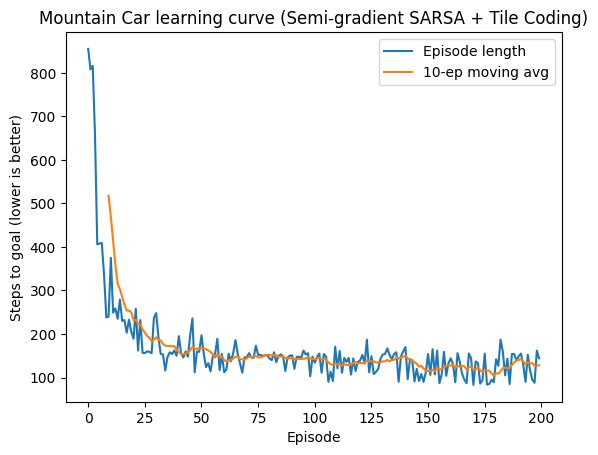

In [19]:
# Baseline configuration
seed = 0
episodes = 200

tc_kwargs = {"n_tilings": 8, "n_x": 8, "n_v": 8}
agent_kwargs = {"alpha": 0.5, "gamma": 1.0, "epsilon": 0.0}

lengths, returns = train(
    seed=seed,
    episodes=episodes,
    tc_kwargs=tc_kwargs,
    agent_kwargs=agent_kwargs,
)

# Plot episode lengths
plt.figure()
plt.plot(lengths, label="Episode length")

# Simple moving average for readability
window = 10
if len(lengths) >= window:
    ma = np.convolve(lengths, np.ones(window) / window, mode="valid")
    plt.plot(np.arange(window - 1, episodes), ma, label=f"{window}-ep moving avg")

plt.xlabel("Episode")
plt.ylabel("Steps to goal (lower is better)")
plt.title("Mountain Car learning curve (Semi-gradient SARSA + Tile Coding)")
plt.legend()
plt.show()


## 6. Effect of step size $\alpha$

Compare several step sizes and plot them together. Compare several values of `alpha` (e.g., 0.1, 0.2, 0.5) and plot learning curves on the same figure.

**Exercise 4.** What happens when $\alpha$ is too small vs too large?


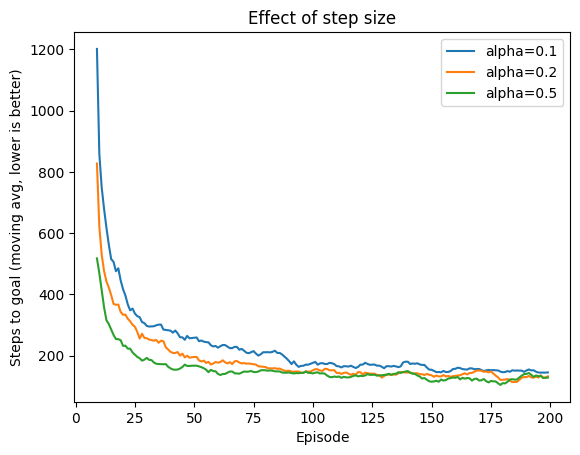

In [20]:
alphas = [0.1, 0.2, 0.5]
seed = 0
episodes = 200

tc_kwargs = {"n_tilings": 8, "n_x": 8, "n_v": 8}

plt.figure()
for alpha in alphas:
    agent_kwargs = {"alpha": alpha, "gamma": 1.0, "epsilon": 0.0}
    lengths, _ = train(
        seed=seed,
        episodes=episodes,
        tc_kwargs=tc_kwargs,
        agent_kwargs=agent_kwargs,
    )
    window = 10
    ma = np.convolve(lengths, np.ones(window) / window, mode="valid")
    plt.plot(np.arange(window - 1, episodes), ma, label=f"alpha={alpha}")

plt.xlabel("Episode")
plt.ylabel("Steps to goal (moving avg, lower is better)")
plt.title("Effect of step size")
plt.legend()
plt.show()


## 7. Effect of the number of tilings

We now study the impact of the number of tilings on learning performance.

Compare different values of `n_tilings` in  
$$
\{1,\;4,\;8,\;16\},
$$
while keeping all other parameters fixed.

**Exercise 5.**
1. Why can increasing the number of tilings improve learning performance?
2. What are the disadvantages of increasing the number of tilings?

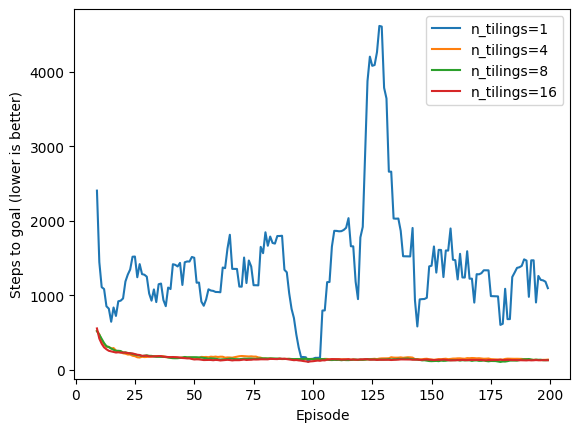

In [21]:
tilings_list = [1, 4, 8, 16]
seed = 0
episodes = 200
alpha = 0.5

plt.figure()
for n_tilings in tilings_list:
    tc_kwargs = {"n_tilings": n_tilings, "n_x": 8, "n_v": 8}
    agent_kwargs = {"alpha": alpha, "gamma": 1.0, "epsilon": 0.0}
    lengths, _ = train(
        seed=seed,
        episodes=episodes,
        tc_kwargs=tc_kwargs,
        agent_kwargs=agent_kwargs,
    )
    window = 10
    ma = np.convolve(lengths, np.ones(window) / window, mode="valid")
    plt.plot(np.arange(window - 1, episodes), ma, label=f"n_tilings={n_tilings}")

plt.xlabel("Episode")
plt.ylabel("Steps to goal (lower is better)")
plt.legend()
plt.show()
